<a href="https://colab.research.google.com/github/mach-ag01/data-science-portfolio/blob/main/01_Heart_Disease_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 — Heart Disease Risk Prediction
**UCI dataset ID:** 45  
**Goal:** Predict whether heart disease is present. This follows the supplied project proposal: cleaning, EDA, Logistic Regression/SVM/Random Forest, cross-validation, and recall-focused evaluation.

> Educational/research project only — not a clinical diagnostic system.

# 🫀 Project 1 — Heart Disease Risk Prediction

## 📚 Notebook Guide

This notebook is organized as a **guided, end-to-end data science project**. Each section has a short text explanation **outside the code cell** before the code runs.

**Workflow:**
1. 🧰 Setup — install tools and import libraries
2. 📥 Data Loading — obtain the UCI Heart Disease dataset
3. 🧹 Data Cleaning — fix missing values and prepare the target
4. 📊 Exploratory Data Analysis — understand patterns in the data
5. ✂️ Train/Test Split — separate learning data from final evaluation data
6. 🤖 Model Building — train Logistic Regression, SVM and Random Forest
7. 🔁 Cross-Validation — compare model performance reliably
8. 🏆 Model Selection — choose the model using the project’s recall priority
9. 🧪 Test Evaluation — measure final performance on unseen data
10. 🔍 Interpretation — inspect confusion matrix, ROC curve and important features
11. 💾 Outputs — save results for reporting and portfolio use

> **Tip:** Run the notebook from top to bottom. The short **“What’s happening”** subtitle before each code section tells you what that step is doing and why it matters.


### 🔎 What’s happening
Installing the Python libraries needed for this project.



In [ ]:
# ============================================================
# COMMON COLAB SETUP
# ============================================================
!pip -q install ucimlrepo xgboost shap imbalanced-learn

import warnings, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


### 🔎 What’s happening
Connecting to the UCI Heart Disease dataset and loading the features and target.



In [ ]:
from ucimlrepo import fetch_ucirepo

heart = fetch_ucirepo(id=45)
X = heart.data.features.copy()
y = heart.data.targets.copy()

print("Features:", X.shape)
print("Target:", y.shape)
display(X.head())
display(y.head())
print(X.dtypes)

Features: (303, 13)
Target: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


### 🔎 What’s happening
Keeping an untouched copy of the downloaded data so the original dataset is preserved.



In [ ]:
# Preserve an untouched raw copy before cleaning.
raw_X = X.copy()
raw_y = y.copy()

# Convert '?' and common missing markers to NaN.
X = X.replace(["?", "NA", "N/A", ""], np.nan)
X = X.apply(pd.to_numeric, errors="coerce")

# The UCI target is commonly represented as 0..4 severity.
target_col = y.columns[0]
y = pd.to_numeric(y[target_col], errors="coerce")

# Binary target: 0 = no disease, >0 = disease present.
y_binary = (y > 0).astype(int)

print("Missing values:")
display(X.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("\nTarget distribution:")
display(y_binary.value_counts().sort_index().rename(index={0:"No disease",1:"Disease"}))

Missing values:


,missing
ca,4
thal,2
cp,0
sex,0
age,0
chol,0
trestbps,0
fbs,0
restecg,0
exang,0



Target distribution:


,count
num,
No disease,164
Disease,139


### 🔎 What’s happening
Filling remaining numeric missing values with the median to make the data model-ready.



In [ ]:
# Drop columns that are completely missing, then median-impute numeric features.
X = X.dropna(axis=1, how="all")
X = X.fillna(X.median(numeric_only=True))

print("Clean shape:", X.shape)
display(X.describe().T)

Clean shape: (303, 13)


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 🔎 What’s happening
Exploring the data visually to understand distributions and the balance between disease and no-disease cases.



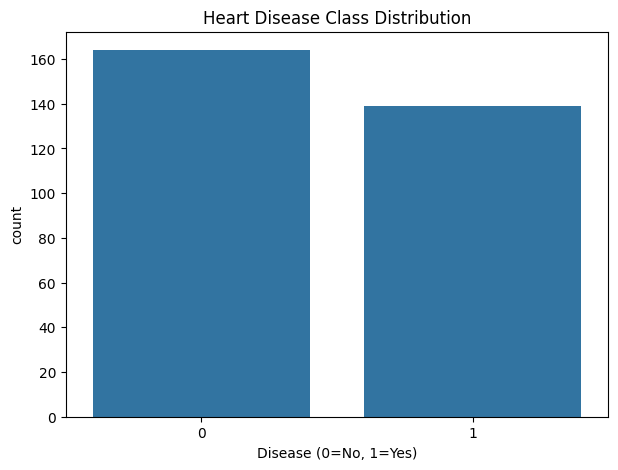

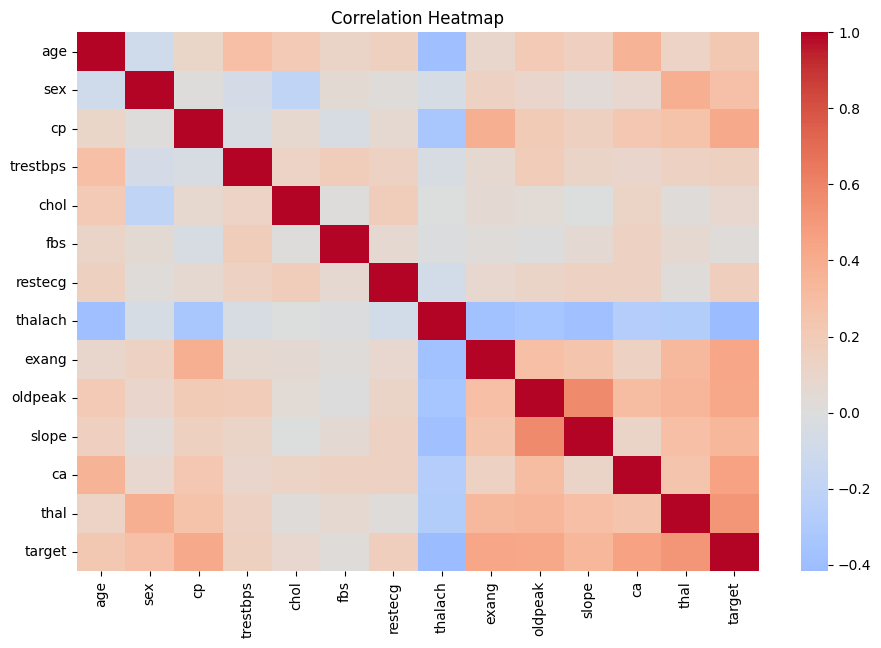

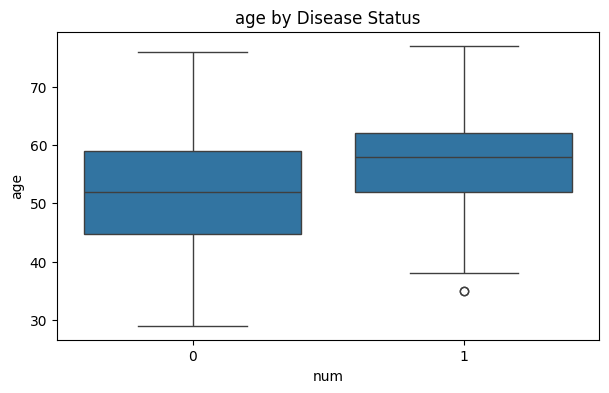

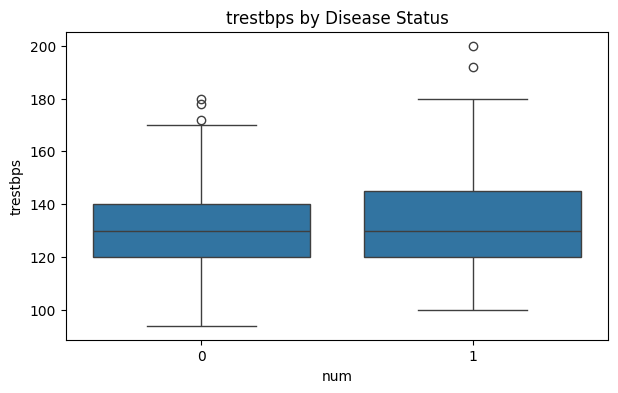

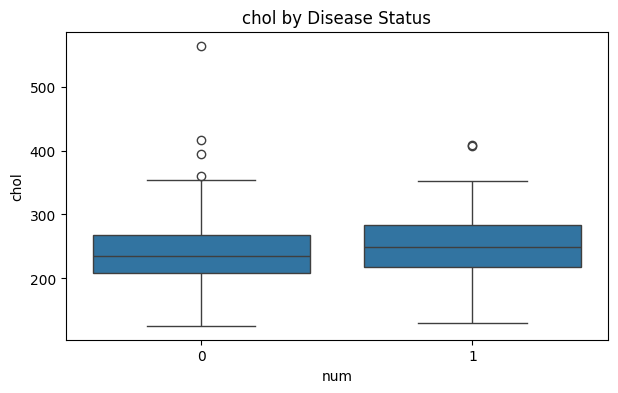

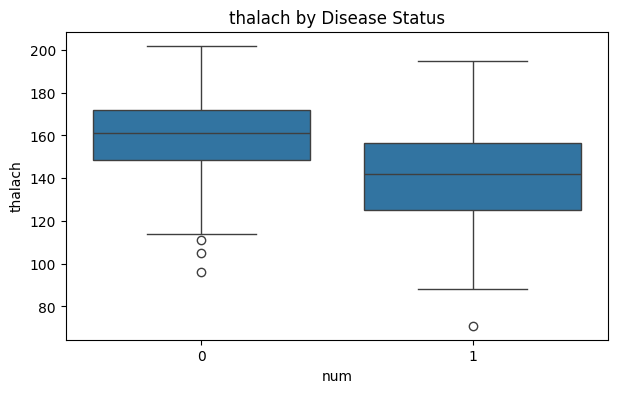

In [ ]:
# EDA
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(x=y_binary, ax=ax)
ax.set_title("Heart Disease Class Distribution")
ax.set_xlabel("Disease (0=No, 1=Yes)")
plt.show()

plt.figure(figsize=(11,7))
sns.heatmap(pd.concat([X, y_binary.rename("target")], axis=1).corr(),
            cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

for col in [c for c in ["age","trestbps","chol","thalach"] if c in X.columns]:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=y_binary, y=X[col])
    plt.title(f"{col} by Disease Status")
    plt.show()

### 🔎 What’s happening
Defining several classification models so we can compare different approaches to the prediction task.



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=400, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1))
    ])
}

scoring = {"accuracy":"accuracy", "precision":"precision",
           "recall":"recall", "f1":"f1", "roc_auc":"roc_auc"}

results = []
for name, model in models.items():
    scores = cross_validate(model, X, y_binary, cv=cv, scoring=scoring)
    results.append({
        "Model": name,
        **{metric: scores[f"test_{metric}"].mean() for metric in scoring}
    })

results_df = pd.DataFrame(results).sort_values("recall", ascending=False)
display(results_df)

,Model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.831585,0.830438,0.798413,0.812617,0.911631
2,Random Forest,0.844918,0.861516,0.791270,0.823938,0.908358
1,SVM,0.838087,0.852606,0.783862,0.815278,0.897508


### 🔎 What’s happening
Comparing model performance and identifying the strongest model, with recall emphasized because missed disease cases matter.



Best model by cross-validated recall: Logistic Regression


,coefficient
thalach,-0.434205
fbs,-0.248337
age,-0.102685
restecg,0.228858
chol,0.236050
oldpeak,0.296240
slope,0.334977
trestbps,0.384385
exang,0.468502
cp,0.566952


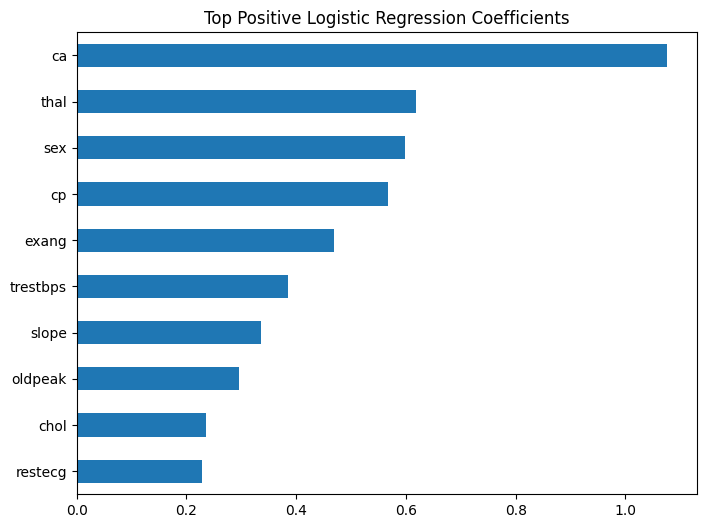

In [ ]:
# Fit the best-recall model on all available data for interpretation.
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_model.fit(X, y_binary)

print("Best model by cross-validated recall:", best_name)

# Feature importance / coefficients
if best_name == "Logistic Regression":
    coef = best_model.named_steps["model"].coef_[0]
    importance = pd.Series(coef, index=X.columns).sort_values()
    display(importance.to_frame("coefficient"))

    plt.figure(figsize=(8,6))
    importance.tail(10).plot(kind="barh")
    plt.title("Top Positive Logistic Regression Coefficients")
    plt.show()
else:
    rf = best_model.named_steps["model"]
    importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    display(importance.head(15).to_frame("importance"))
    importance.head(15).sort_values().plot(kind="barh", figsize=(8,6))
    plt.title("Top Feature Importances")
    plt.show()

### 🔎 What’s happening
Saving the cleaned data, model results and analysis outputs so the project can be reused or documented.



In [ ]:
# Reproducible outputs
os.makedirs("project1_outputs", exist_ok=True)
X.to_csv("project1_outputs/heart_features_clean.csv", index=False)
pd.DataFrame({"target": y_binary}).to_csv("project1_outputs/heart_target.csv", index=False)
results_df.to_csv("project1_outputs/model_comparison.csv", index=False)

print("Saved cleaned data and model comparison in project1_outputs/")

Saved cleaned data and model comparison in project1_outputs/


## Completion checklist
- [ ] Explain the prediction problem and why recall matters.
- [ ] Show missing-value handling and target binarization.
- [ ] Include class distribution and correlation/lifestyle plots.
- [ ] Compare Logistic Regression, SVM and Random Forest.
- [ ] Report accuracy, precision, recall, F1 and ROC-AUC.
- [ ] Explain the most important predictors without claiming causation.
- [ ] State limitations: small sample, observational data, and dataset/mirror leakage checks.